# Renewable Energy Site Suitability — Exploration & Modeling

## Section 1: Exploratory Data Analysis (EDA)

This notebook looks at five years (2019–2023) of averaged climate and resource data for 31 Indian states/UTs, to get a first read on which regions look promising for solar and wind development. Each region is represented by a single row: its long-term average conditions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed_regions.csv")
df.head()

,region,Latitude,Longitude,wind,solar,biomass,hydro,air_temp,albedo,clearsky_dhi,...,cloud_opacity,dni,ghi,gti,precipitation_rate,relative_humidity,surface_pressure,wind_speed_100m,months_of_data,data_quality_flag
0,Andhra Pradesh,15.9129,79.7400,638.931854,597.210398,8.470187,40.489687,28.779033,0.157822,85.989307,...,30.490705,116.330725,197.773435,199.503339,0.116224,70.927288,999.615002,4.181203,60,NaN
1,Arunachal Pradesh,15.9129,79.7400,0.000000,0.479250,0.000000,0.033317,18.736127,0.119500,66.918347,...,42.204292,98.925340,145.233528,156.180827,0.542196,80.787489,990.008052,1.501961,60,NaN
2,Assam,31.1048,77.1734,0.000000,9.271589,0.000000,2.730132,18.736127,0.119500,66.918347,...,42.204292,98.925340,145.233528,156.180827,0.542196,80.787489,990.008052,1.501961,60,NaN
3,Bihar,25.0961,85.3131,0.000000,13.605431,0.805916,3.716998,25.848404,0.163394,96.428726,...,26.503871,105.249823,181.210915,188.523946,0.159579,72.383778,997.143134,4.340661,60,NaN
4,Chandigarh,30.7333,76.7794,1.041133,0.000000,0.000000,0.032667,23.498719,0.164977,81.020224,...,22.071189,156.850890,193.796085,211.656389,0.089705,65.619981,991.246664,3.535373,60,NaN


### 1. Summary statistics

The table below summarizes the key resource and climate variables across all 31 regions: the average, spread (std dev), minimum, maximum, and quartiles.

**In plain English:** this tells us the typical range of conditions across India, and how much regions differ from one another. A wide spread on `gti` (solar irradiance) or `wind_speed_100m`, for example, means location choice matters a lot for solar/wind output — some regions are meaningfully better bets than others.

In [2]:
key_cols = ["gti", "dni", "ghi", "wind_speed_100m", "air_temp", "cloud_opacity", "relative_humidity"]
summary_stats = df[key_cols].describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
gti,31.0,202.514949,20.018209,156.180827,193.840495,204.827030,212.366787,250.818582
dni,31.0,133.432437,36.847991,22.271556,114.694000,134.182987,147.916021,223.052514
ghi,31.0,189.725773,20.697377,133.429047,183.469970,193.796085,200.575607,223.011362
wind_speed_100m,31.0,4.891417,6.823388,1.172583,1.867139,3.692286,4.260932,30.000000
air_temp,31.0,23.310566,8.527417,-5.987930,20.410828,25.252872,26.287021,50.000000
cloud_opacity,31.0,36.252609,39.436323,21.095302,24.344559,28.795481,32.510576,246.487824
relative_humidity,31.0,69.932314,15.381913,0.098162,65.800059,71.662166,80.090941,85.129408


### 2a. Top 10 regions by solar potential (GTI)

GTI (Global Tilted Irradiance) is a measure of how much usable sunlight hits a tilted solar panel — higher is better for solar projects.

**In plain English:** this chart ranks the 10 sunniest regions in our data. These are the states where solar panels would generate the most electricity per unit installed, all else being equal.

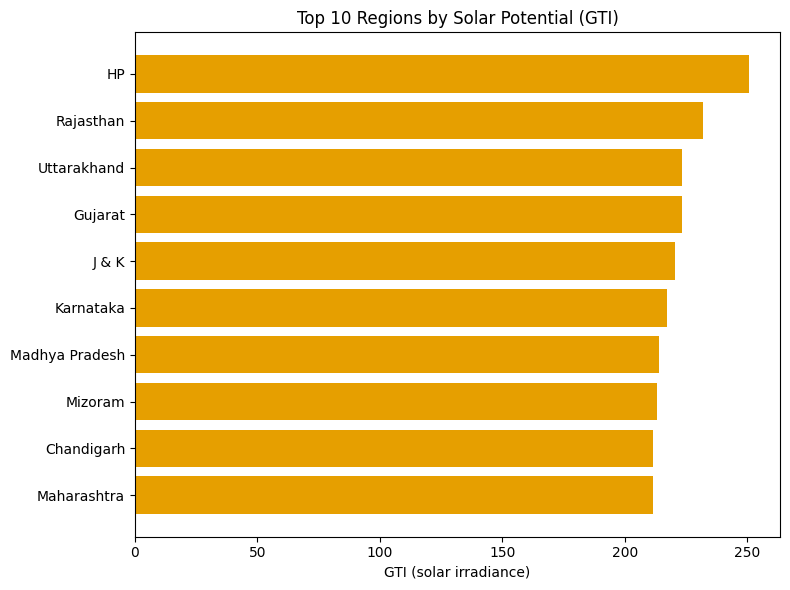

In [3]:
top10_gti = df.nlargest(10, "gti").sort_values("gti")

plt.figure(figsize=(8, 6))
plt.barh(top10_gti["region"], top10_gti["gti"], color="#e69f00")
plt.xlabel("GTI (solar irradiance)")
plt.title("Top 10 Regions by Solar Potential (GTI)")
plt.tight_layout()
plt.show()

### 2b. Top 10 regions by wind potential (wind speed at 100m)

Wind speed at 100 meters is roughly hub height for a modern wind turbine — the higher the wind speed, the more energy a turbine can capture.

**In plain English:** this chart ranks the 10 windiest regions in our data. These are the states best suited for wind farms based purely on average wind resource.

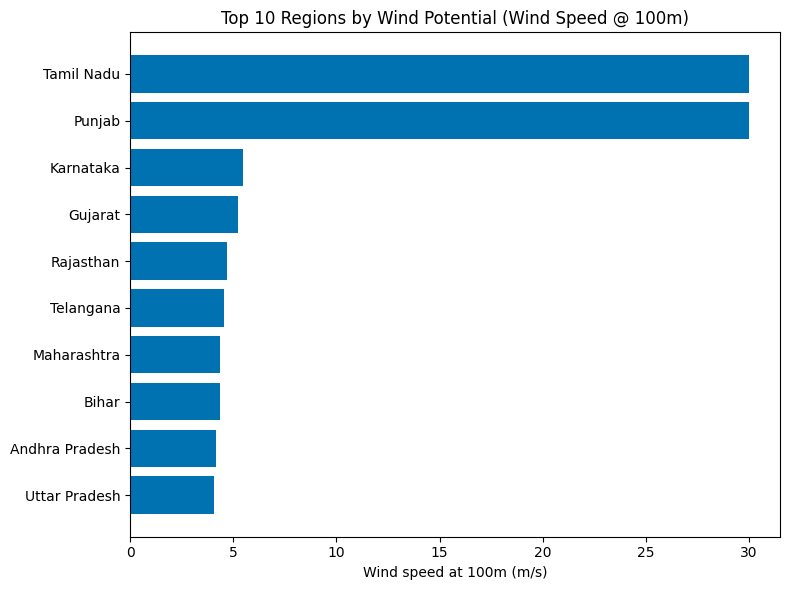

In [4]:
top10_wind = df.nlargest(10, "wind_speed_100m").sort_values("wind_speed_100m")

plt.figure(figsize=(8, 6))
plt.barh(top10_wind["region"], top10_wind["wind_speed_100m"], color="#0072b2")
plt.xlabel("Wind speed at 100m (m/s)")
plt.title("Top 10 Regions by Wind Potential (Wind Speed @ 100m)")
plt.tight_layout()
plt.show()

### 3. Correlation heatmap

This heatmap shows how strongly every pair of numeric variables moves together, from -1 (strong opposite relationship) to +1 (strong matching relationship).

**In plain English:** this is a quick way to spot which conditions tend to come as a package. For example, if solar-related variables (`gti`, `dni`, `ghi`) are all highly correlated with each other but not with wind speed, that tells us solar and wind potential are largely independent — a region can be strong in one, both, or neither.

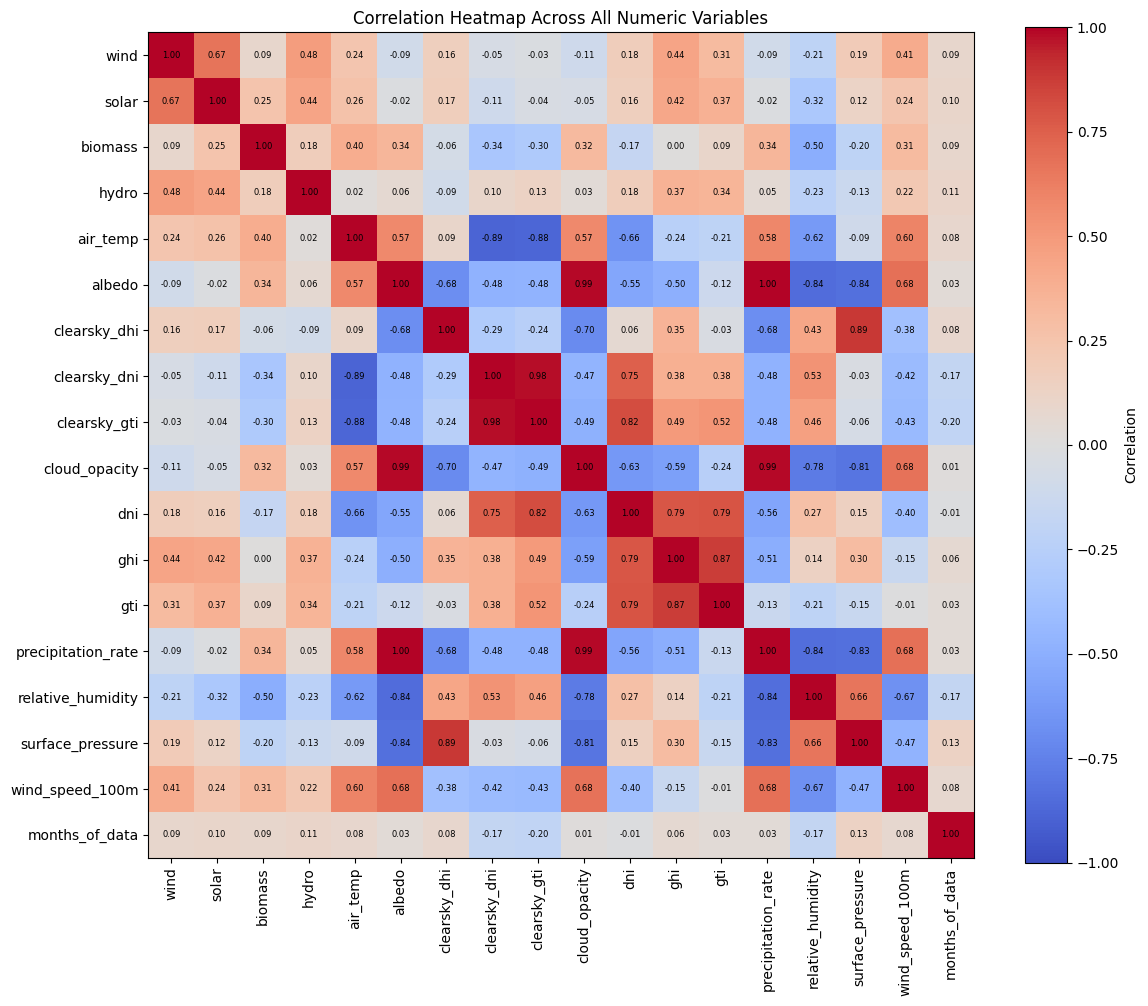

In [5]:
numeric_df = df.select_dtypes(include="number").drop(columns=["Latitude", "Longitude"], errors="ignore")
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Heatmap Across All Numeric Variables")
plt.tight_layout()
plt.show()

### 4. Solar vs. wind potential by region

This scatter plot places every region by its solar potential (GTI, x-axis) and wind potential (wind speed at 100m, y-axis), with each dot colored by region.

**In plain English:** regions in the upper-right are strong candidates for *hybrid* solar+wind projects — they score well on both resources. Regions far to the right but low on the chart are solar-only bets; regions high up but to the left are wind-only bets. This is a fast way to shortlist multi-resource sites for further evaluation.

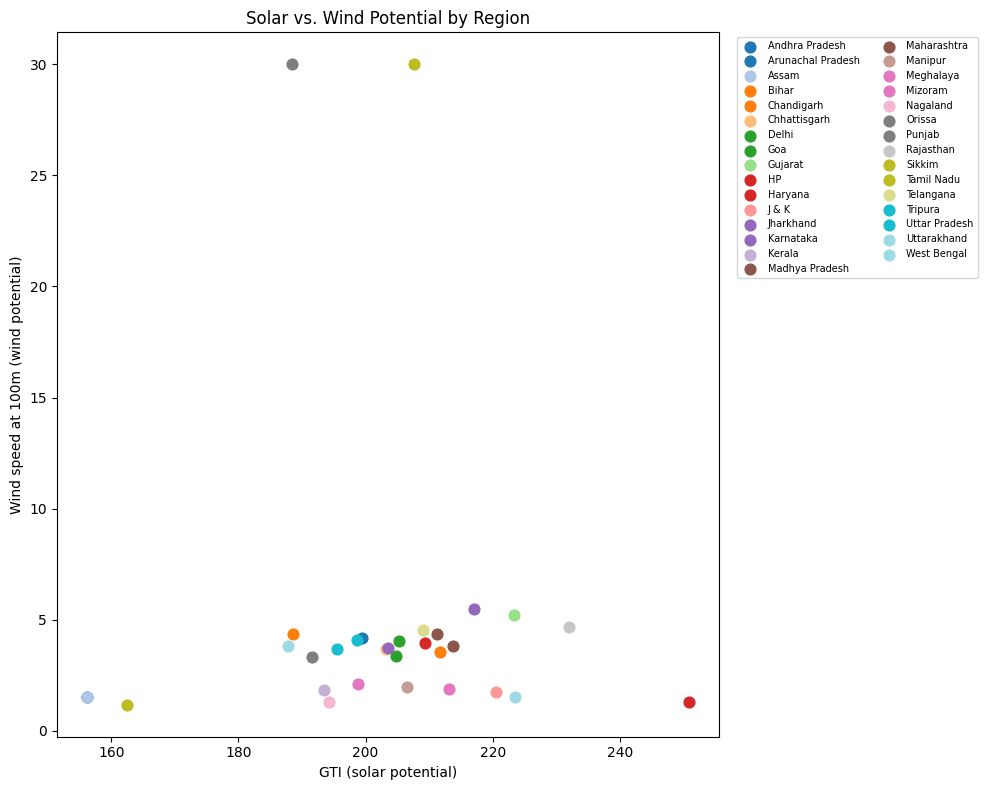

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

regions = df["region"].unique()
cmap = plt.get_cmap("tab20", len(regions))
color_map = {region: cmap(i) for i, region in enumerate(regions)}

for region in regions:
    row = df[df["region"] == region]
    ax.scatter(row["gti"], row["wind_speed_100m"], color=color_map[region], label=region, s=60)

ax.set_xlabel("GTI (solar potential)")
ax.set_ylabel("Wind speed at 100m (wind potential)")
ax.set_title("Solar vs. Wind Potential by Region")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## Section 2: Modeling

This section turns the raw resource data into an actionable **suitability score** per region (0–100), groups regions into potential tiers, sanity-checks those groupings, and tests how sensitive the ranking is to different investment priorities (solar-first vs. wind-first).

In [7]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / "src"))

from src.main import build_suitability_index, cluster_regions, validate_clusters, DEFAULT_WEIGHTS

scored_df = build_suitability_index(df, DEFAULT_WEIGHTS)
scored_df = cluster_regions(scored_df)

print("Weights used:", DEFAULT_WEIGHTS)
scored_df[["region", "suitability_score", "cluster_label"]].head()

Weights used: {'solar': 0.4, 'wind': 0.3, 'cloud': 0.15, 'humidity': 0.15}


,region,suitability_score,cluster_label
0,Andhra Pradesh,38.321944,Low Potential
1,Arunachal Pradesh,14.703900,Low Potential
2,Assam,14.703900,Low Potential
3,Bihar,33.855683,Low Potential
4,Chandigarh,44.283067,Medium Potential


### 1. Top 10 regions by suitability score

The table below is the model's headline output: a single 0–100 score per region that blends solar potential, wind potential, cloud cover, and humidity into one number, using the default weighting (40% solar, 30% wind, 15% cloud, 15% humidity).

**In plain English:** this is the shortlist. The higher the score, the more favorable the overall climate conditions for a renewable energy project in that region, combining both solar and wind factors rather than looking at just one.

In [8]:
top10_suitability = scored_df[["region", "suitability_score", "cluster_label", "data_quality_flag"]].sort_values(
    "suitability_score", ascending=False
).head(10).reset_index(drop=True)
top10_suitability.index = top10_suitability.index + 1
top10_suitability.insert(
    1,
    "Flag",
    top10_suitability["data_quality_flag"].apply(lambda flag: "⚠️ wind capped" if flag == "wind_speed_capped" else ""),
)
top10_suitability = top10_suitability.drop(columns=["data_quality_flag"])
top10_suitability

,region,Flag,suitability_score,cluster_label
1,Tamil Nadu,⚠️ wind capped,68.632291,Medium Potential
2,Punjab,⚠️ wind capped,58.635940,High Potential
3,HP,,57.077127,Medium Potential
4,Rajasthan,,56.305554,Medium Potential
5,Gujarat,,52.431431,Medium Potential
6,Karnataka,,47.945761,Medium Potential
7,Uttarakhand,,45.818926,Medium Potential
8,J & K,,45.718887,Medium Potential
9,Madhya Pradesh,,45.502077,Medium Potential
10,Maharashtra,,45.400064,Medium Potential


### 2. Solar vs. wind potential, colored by cluster

Same axes as the Section 1 scatter plot (GTI vs. wind speed at 100m), but now each region is colored by the potential tier the model assigned it to, instead of by region identity.

**In plain English:** this shows visually how the model grouped regions. If the coloring lines up cleanly with position on the chart (e.g. "High Potential" dots clustered in the upper-right), the grouping matches intuition. If the colors look mixed together with no clear separation, that's a sign the tiers are more about the full weighted formula (which also factors in cloud cover and humidity) than about solar/wind alone — or that the cluster boundaries are landing awkwardly between similarly-scored regions.

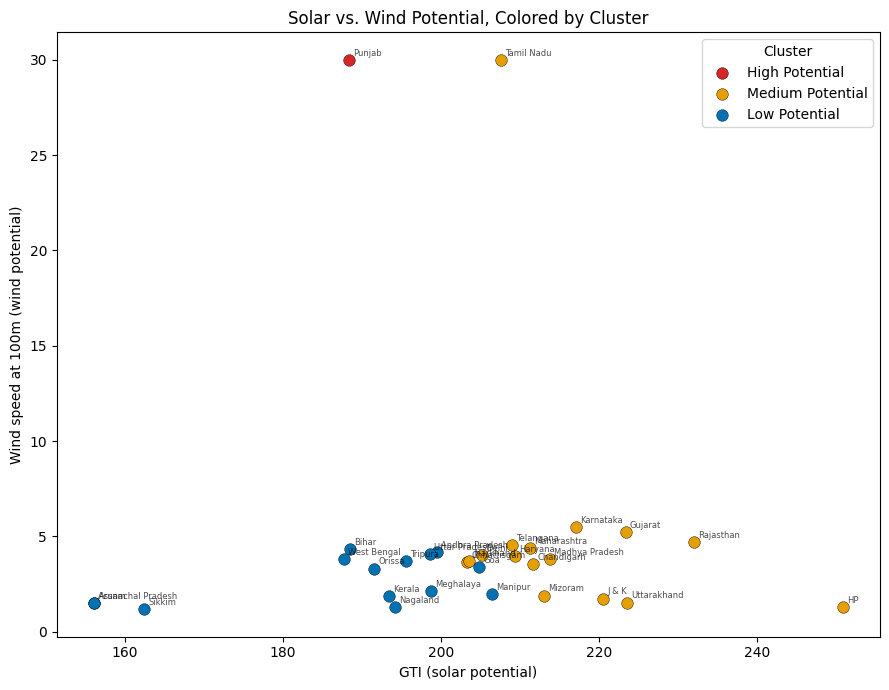

In [9]:
cluster_colors = {
    "High Potential": "#d62728",
    "Medium Potential": "#e69f00",
    "Low Potential": "#0072b2",
}

fig, ax = plt.subplots(figsize=(9, 7))

for label, color in cluster_colors.items():
    subset = scored_df[scored_df["cluster_label"] == label]
    ax.scatter(subset["gti"], subset["wind_speed_100m"], color=color, label=label, s=70, edgecolor="black", linewidth=0.3)

for _, row in scored_df.iterrows():
    ax.annotate(row["region"], (row["gti"], row["wind_speed_100m"]), fontsize=6, alpha=0.7,
                xytext=(3, 3), textcoords="offset points")

ax.set_xlabel("GTI (solar potential)")
ax.set_ylabel("Wind speed at 100m (wind potential)")
ax.set_title("Solar vs. Wind Potential, Colored by Cluster")
ax.legend(title="Cluster")
plt.tight_layout()
plt.show()

### 3. Cluster validation

Two numbers below check whether the clustering is actually trustworthy, not just cosmetically neat:

- **Spearman correlation** (suitability rank vs. cluster-average rank, range -1 to 1): checks that a region's individual suitability rank agrees with the rank of the tier it was placed in. A value near 1 means the tiers are internally consistent with the underlying score — a region isn't randomly dropped into a tier that contradicts its own score.
- **Silhouette score** (range -1 to 1): measures how well-separated the clusters are — how much closer each region is to others in its own tier than to regions in a different tier. Above ~0.5 is considered strong separation; 0.25–0.5 is moderate (tiers are meaningfully different but boundaries have some fuzziness); near 0 or negative means the groupings are essentially arbitrary.

**In plain English:** the Spearman number tells us "do the tiers make sense given the scores," and the silhouette number tells us "are the tiers cleanly distinct groups, or just an arbitrary cut through a continuous spread of similar regions."

In [10]:
spearman_corr, sil_score = validate_clusters(scored_df)

Spearman correlation (suitability rank vs. cluster-avg rank): 0.8743
Silhouette score: 0.3351


### 4. Scenario comparison: does the ranking depend on investment priorities?

The default weighting (40% solar / 30% wind / 15% cloud / 15% humidity) is one point of view. Here we re-run `build_suitability_index` with two alternative weight profiles to see how sensitive the ranking is to that choice:

- **Solar-heavy**: `{"solar": 0.6, "wind": 0.15, "cloud": 0.15, "humidity": 0.1}` — prioritizes solar developers.
- **Wind-heavy**: `{"solar": 0.15, "wind": 0.6, "cloud": 0.15, "humidity": 0.1}` — the mirror image, prioritizing wind developers.

**In plain English:** if a region's rank barely moves across all three weightings, it's a genuinely strong, balanced site. If a region jumps dramatically (e.g. top 5 under solar-heavy but bottom half under wind-heavy), that tells us its appeal is really driven by one resource, not both — useful to know before committing to a technology choice for that site.

In [11]:
scenarios = {
    "Default": DEFAULT_WEIGHTS,
    "Solar-heavy": {"solar": 0.6, "wind": 0.15, "cloud": 0.15, "humidity": 0.1},
    "Wind-heavy": {"solar": 0.15, "wind": 0.6, "cloud": 0.15, "humidity": 0.1},
}

raw_regions = pd.read_csv("../data/processed_regions.csv")

scenario_scores = {}
for name, weights in scenarios.items():
    result = build_suitability_index(raw_regions, weights)
    scenario_scores[name] = result.set_index("region")["suitability_score"]

scenario_df = pd.DataFrame(scenario_scores)
for name in scenarios:
    scenario_df[f"{name} rank"] = scenario_df[name].rank(ascending=False).astype(int)

# Any region that lands in the top 10 under at least one weighting scheme
rank_cols = [f"{name} rank" for name in scenarios]
in_any_top10 = (scenario_df[rank_cols] <= 10).any(axis=1)
comparison = scenario_df.loc[in_any_top10, rank_cols].sort_values("Default rank")
comparison

,Default rank,Solar-heavy rank,Wind-heavy rank
region,,,
Tamil Nadu,1,3,1
Punjab,2,19,2
HP,3,1,10
Rajasthan,4,2,3
Gujarat,5,4,4
Karnataka,6,7,5
Uttarakhand,7,5,19
J & K,8,6,17
Madhya Pradesh,9,8,9
